In [22]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [23]:
# Load dataset
df = pd.read_csv("/content/exchange_rate.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y %H:%M")

# Set date as index
df.set_index('date', inplace=True)

# Rename exchange rate column for clarity
df.rename(columns={'Ex_rate': 'USD_to_AUD'}, inplace=True)

# Sort by date
df.sort_index(inplace=True)

print(df.head())
print(df.info())

            USD_to_AUD
date                  
1990-01-01      0.7855
1990-01-02      0.7818
1990-01-03      0.7867
1990-01-04      0.7860
1990-01-05      0.7849
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   USD_to_AUD  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None


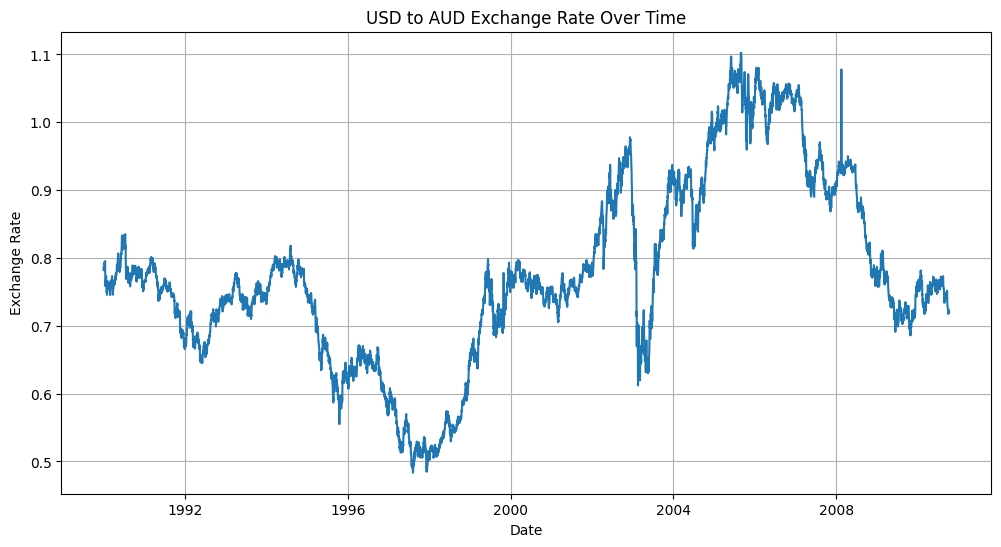

Missing values:
 USD_to_AUD    0
dtype: int64


In [24]:
# Plot time series
plt.figure(figsize=(12,6))
plt.plot(df['USD_to_AUD'])
plt.title("USD to AUD Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

# Check missing values
print("Missing values:\n", df.isnull().sum())

In [25]:
df.fillna(method='ffill', inplace=True)

In [26]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])

print("ADF Test on Original Series")
adf_test(df['USD_to_AUD'])

ADF Test on Original Series
ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477
Critical Values: {'1%': np.float64(-3.4312123140180137), '5%': np.float64(-2.861921078147796), '10%': np.float64(-2.5669728434336108)}


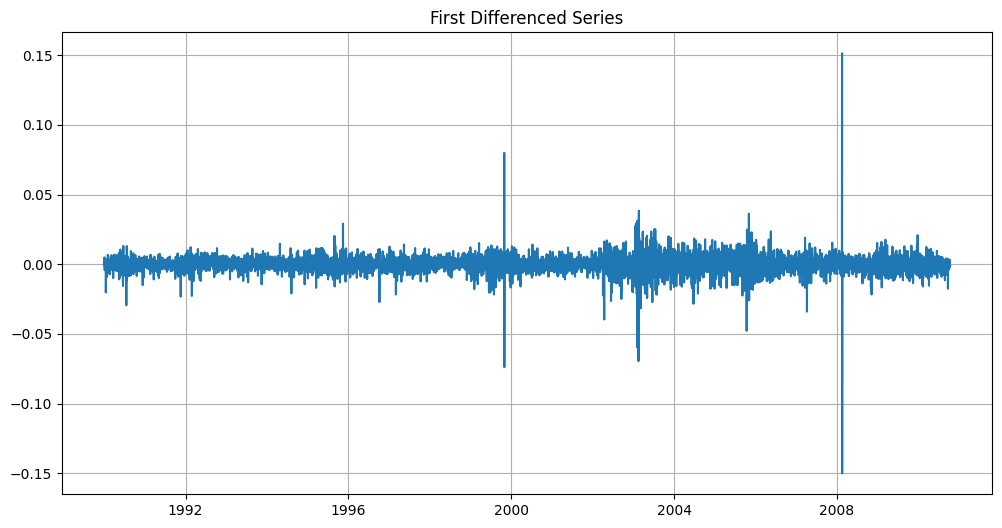

ADF Test After Differencing
ADF Statistic: -99.39343120118632
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4312123140180137), '5%': np.float64(-2.861921078147796), '10%': np.float64(-2.5669728434336108)}


In [27]:
df_diff = df['USD_to_AUD'].diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(df_diff)
plt.title("First Differenced Series")
plt.grid(True)
plt.show()

print("ADF Test After Differencing")
adf_test(df_diff)

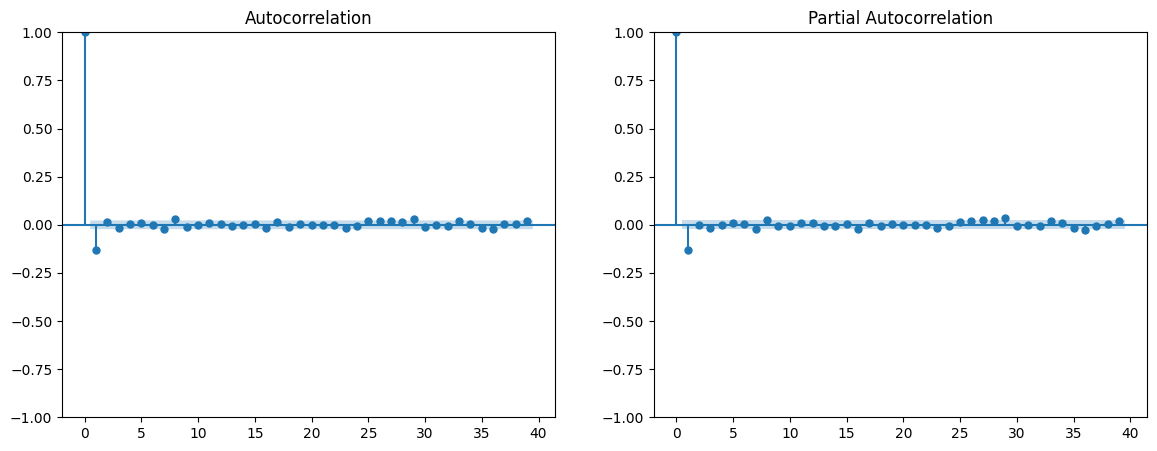

In [28]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(df_diff, ax=ax[0])
plot_pacf(df_diff, ax=ax[1])

plt.show()

In [29]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 6070
Test size: 1518


In [30]:
model_arima = ARIMA(train['USD_to_AUD'], order=(1,1,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             USD_to_AUD   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Wed, 25 Feb 2026   AIC                         -45432.092
Time:                        14:34:48   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

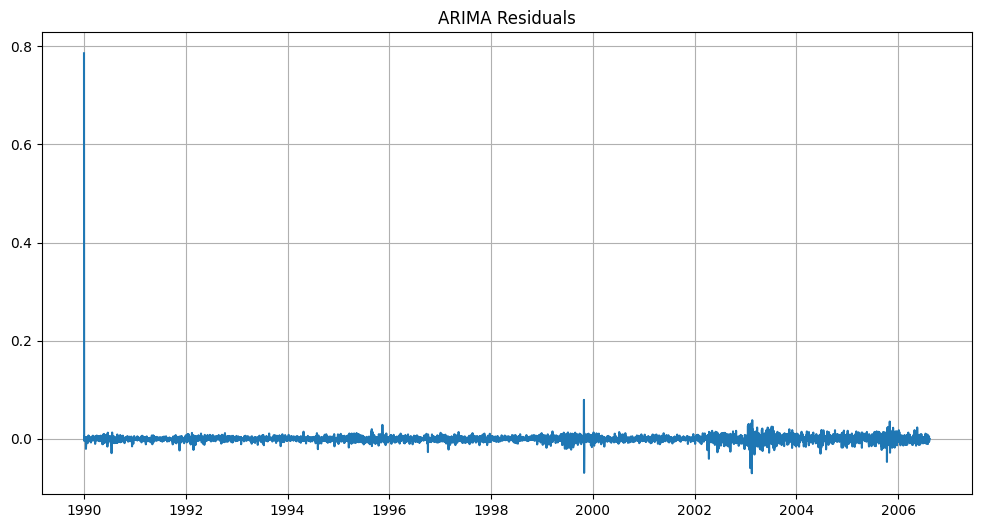

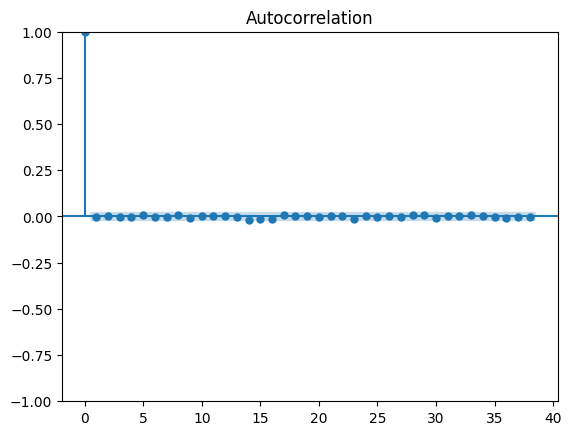

In [31]:
residuals = model_arima_fit.resid

plt.figure(figsize=(12,6))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.grid(True)
plt.show()

plot_acf(residuals)
plt.show()

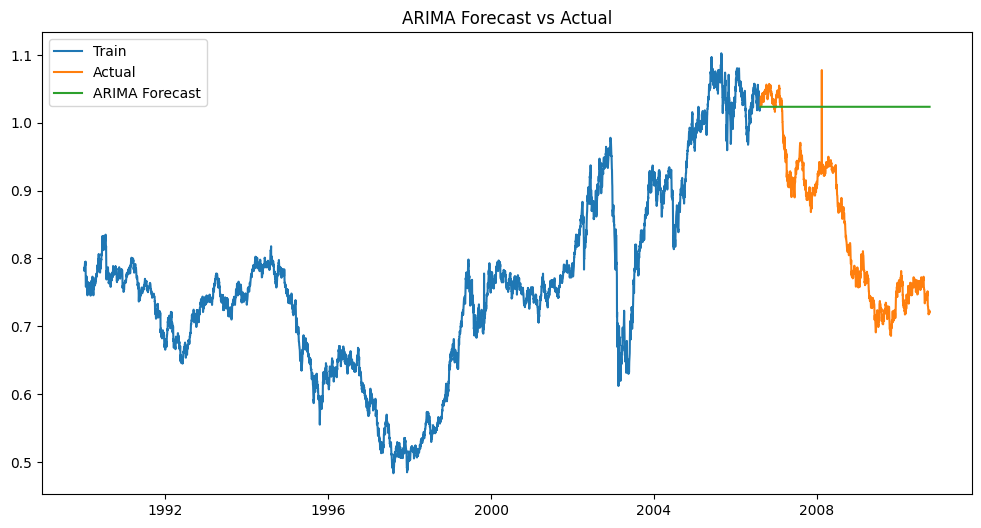

In [32]:
forecast_arima = model_arima_fit.forecast(steps=len(test))

plt.figure(figsize=(12,6))
plt.plot(train.index, train['USD_to_AUD'], label='Train')
plt.plot(test.index, test['USD_to_AUD'], label='Actual')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [33]:
model_es = ExponentialSmoothing(
    train['USD_to_AUD'],
    trend='add',
    seasonal=None
)

model_es_fit = model_es.fit()

forecast_es = model_es_fit.forecast(steps=len(test))

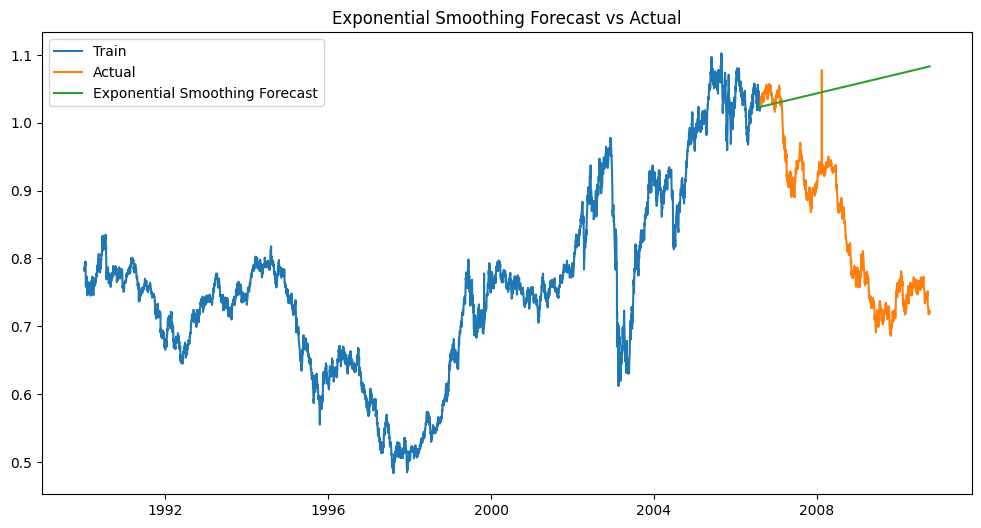

In [34]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['USD_to_AUD'], label='Train')
plt.plot(test.index, test['USD_to_AUD'], label='Actual')
plt.plot(test.index, forecast_es, label='Exponential Smoothing Forecast')
plt.legend()
plt.title("Exponential Smoothing Forecast vs Actual")
plt.show()

In [35]:
def evaluate(true, predicted):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    mape = np.mean(np.abs((true - predicted) / true)) * 100
    return mae, rmse, mape

mae_arima, rmse_arima, mape_arima = evaluate(test['USD_to_AUD'], forecast_arima)
mae_es, rmse_es, mape_es = evaluate(test['USD_to_AUD'], forecast_es)

print("ARIMA Performance")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)

print("\nExponential Smoothing Performance")
print("MAE:", mae_es)
print("RMSE:", rmse_es)
print("MAPE:", mape_es)

ARIMA Performance
MAE: 0.17770970449121345
RMSE: 0.2054366965966928
MAPE: 22.797966173811552

Exponential Smoothing Performance
MAE: 0.20659619114093827
RMSE: 0.23910443161792286
MAPE: 26.50866379878783


In [36]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Exponential Smoothing"],
    "MAE": [mae_arima, mae_es],
    "RMSE": [rmse_arima, rmse_es],
    "MAPE": [mape_arima, mape_es]
})

print(comparison)

                   Model       MAE      RMSE       MAPE
0                  ARIMA  0.177710  0.205437  22.797966
1  Exponential Smoothing  0.206596  0.239104  26.508664
